In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#Listagem dos voos

from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

print("Total de voos encontrados:", len(flights))

for f in flights:
    print(f.name)

Total de voos encontrados: 47
carbonZ_2018-07-18-12-10-11_no_ground_truth
carbonZ_2018-07-18-15-53-31_1_engine_failure
carbonZ_2018-07-18-15-53-31_2_engine_failure
carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-39-00_1_engine_failure
carbonZ_2018-07-30-16-39-00_2_engine_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-36-35_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-46-31_engine_failure_with_emr_traj
carbonZ_2018-09-11-11-56-30_engine_failure
carbonZ_2018-09-11-14-16-55_no_failure
carbonZ_2018-09-11-14-22-07_1_engine_failure
carbonZ_2018-09-11-14-22-07_2_engine_failure
carbonZ_2018-09-11-14-41-38_no_failure
carbonZ_2018-09-11-14-41-51_elevator_failure
carbonZ

In [ ]:
# Conferir se cada pasta de voo dentro do seu Google Drive contém o arquivo CSV consolidado esperado.

from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

rows = []

for flight in flights:
    consolidated_path = flight / "flight_consolidated.csv"

    rows.append({
        "flight": flight.name,
        "has_consolidated": consolidated_path.exists()
    })

check_df = pd.DataFrame(rows)

print(check_df.head())
print("\nResumo:")
print(check_df["has_consolidated"].value_counts())

                                              flight  has_consolidated
0        carbonZ_2018-07-18-12-10-11_no_ground_truth              True
1       carbonZ_2018-07-18-15-53-31_1_engine_failure              True
2       carbonZ_2018-07-18-15-53-31_2_engine_failure              True
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...              True
4           carbonZ_2018-07-18-16-37-39_1_no_failure              True

Resumo:
has_consolidated
True    47
Name: count, dtype: int64


In [ ]:
# Entrando nos dados para realizar um cálculo físico da aceleração e do Jerk

from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

def compute_jerk_metrics(flight_dir):
    csv_path = flight_dir / "flight_consolidated.csv"

    df = pd.read_csv(csv_path)

    needed = ["time_s", "vx_mps", "vy_mps"]

    for col in needed:
        if col not in df.columns:
            return {"flight": flight_dir.name, "status": "missing_column"}

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=needed)

    if len(df) < 10:
        return {"flight": flight_dir.name, "status": "few_points"}

    t = df["time_s"].to_numpy(dtype=float)
    vx = df["vx_mps"].to_numpy(dtype=float)
    vy = df["vy_mps"].to_numpy(dtype=float)

    eps = 1e-9

    dt = np.gradient(t)
    dt[dt == 0] = eps

    # aceleração
    ax = np.gradient(vx) / (dt + eps)
    ay = np.gradient(vy) / (dt + eps)

    # jerk
    jx = np.gradient(ax) / (dt + eps)
    jy = np.gradient(ay) / (dt + eps)

    jerk = np.sqrt(jx**2 + jy**2)

    return {
        "flight": flight_dir.name,
        "status": "ok",
        "jerk_mean": float(np.mean(jerk)),
        "jerk_std": float(np.std(jerk)),
        "jerk_max": float(np.max(jerk))
    }

rows = []

for i, flight in enumerate(flights, start=1):
    rows.append(compute_jerk_metrics(flight))

    if i % 10 == 0 or i == len(flights):
        print(f"{i}/{len(flights)} voos processados")

df_jerk = pd.DataFrame(rows)

print("\nPrimeiras linhas:")
print(df_jerk.head())

10/47 voos processados
20/47 voos processados
30/47 voos processados
40/47 voos processados
47/47 voos processados

Primeiras linhas:
                                              flight status  jerk_mean  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth     ok   4.673840   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure     ok   3.419181   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure     ok   2.491143   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...     ok   3.776838   
4           carbonZ_2018-07-18-16-37-39_1_no_failure     ok   4.867347   

   jerk_std   jerk_max  
0  3.951012  27.333625  
1  3.143519  22.727741  
2  2.408459  21.181060  
3  3.247228  24.709631  
4  4.243016  18.045749  


In [ ]:
# Aqui utilizamos os cálculos de jerk no script anterior e os agrupamos para responder à pergunta:
#"Existe diferença no comportamento físico entre voos com falha e voos sem falha?"

import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

# adicionar tipo de voo
df_jerk["flight_type"] = df_jerk["flight"].apply(lambda x:
    "engine_failure" if "engine_failure" in x else
    "no_failure" if "no_failure" in x else
    "other"
)

df_ok = df_jerk[df_jerk["status"] == "ok"]

summary = df_ok.groupby("flight_type")[[
    "jerk_mean",
    "jerk_std",
    "jerk_max"
]].mean()

print(summary)

                jerk_mean  jerk_std   jerk_max
flight_type                                   
engine_failure   3.495174  3.305444  24.160875
no_failure       4.280546  3.641290  20.274027
other            3.449488  3.410965  23.177979


In [ ]:
# Aqui temos um filtro de qualidade Física, que serve para identificar se os dados de um voo fazem sentido do ponto de vista físico ou se contêm ruídos,
#erros de sensor ou manobras humanamente impossíveis.

def physical_consistency_check_v2(flight_dir):
    csv_path = flight_dir / "flight_consolidated.csv"
    df = pd.read_csv(csv_path)

    needed = ["time_s", "vx_mps", "vy_mps"]

    for col in needed:
        if col not in df.columns:
            return {"flight": flight_dir.name, "status": "missing_column"}

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=needed)

    if len(df) < 10:
        return {"flight": flight_dir.name, "status": "few_points"}

    t = df["time_s"].to_numpy(dtype=float)
    vx = df["vx_mps"].to_numpy(dtype=float)
    vy = df["vy_mps"].to_numpy(dtype=float)

    eps = 1e-9

    dt = np.gradient(t)
    dt[dt == 0] = eps

    ax = np.gradient(vx) / (dt + eps)
    ay = np.gradient(vy) / (dt + eps)

    acc = np.sqrt(ax**2 + ay**2)

    jx = np.gradient(ax) / (dt + eps)
    jy = np.gradient(ay) / (dt + eps)

    jerk = np.sqrt(jx**2 + jy**2)

    # novos thresholds (baseados nos dados)
    acc_threshold = 10.0
    jerk_threshold = 30.0

    acc_flag = acc > acc_threshold
    jerk_flag = jerk > jerk_threshold

    return {
        "flight": flight_dir.name,
        "status": "ok",
        "acc_violation_rate": float(np.mean(acc_flag)),
        "jerk_violation_rate": float(np.mean(jerk_flag)),
        "max_acc": float(np.max(acc)),
        "max_jerk": float(np.max(jerk))
    }

rows = []

for i, flight in enumerate(flights, start=1):
    rows.append(physical_consistency_check_v2(flight))

    if i % 10 == 0 or i == len(flights):
        print(f"{i}/{len(flights)} voos processados")

df_phys2 = pd.DataFrame(rows)

print("\nPrimeiras linhas:")
print(df_phys2.head())

10/47 voos processados
20/47 voos processados
30/47 voos processados
40/47 voos processados
47/47 voos processados

Primeiras linhas:
                                              flight status  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth     ok   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure     ok   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure     ok   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...     ok   
4           carbonZ_2018-07-18-16-37-39_1_no_failure     ok   

   acc_violation_rate  jerk_violation_rate   max_acc   max_jerk  
0                 0.0                  0.0  7.857327  27.333625  
1                 0.0                  0.0  7.581974  22.727741  
2                 0.0                  0.0  5.768005  21.181060  
3                 0.0                  0.0  7.414259  24.709631  
4                 0.0                  0.0  6.532085  18.045749  


In [ ]:
# Agrupamento estatístico dos picos de movimento, ou seja, maiores jerks e aceleração.

df_phys2["flight_type"] = df_phys2["flight"].apply(lambda x:
    "engine_failure" if "engine_failure" in x else
    "no_failure" if "no_failure" in x else
    "other"
)

df_ok = df_phys2[df_phys2["status"] == "ok"]

summary = df_ok.groupby("flight_type")[[
    "max_acc",
    "max_jerk"
]].mean()

print(summary)

                 max_acc   max_jerk
flight_type                        
engine_failure  8.187565  24.160875
no_failure      6.692051  20.274027
other           7.553562  23.177979


In [ ]:
# Neste bloco estabelecemos um 'baseline' estatístico utilizando apenas voos normais
# (no_failure). Para cada voo do dataset, calcula-se um score de desvio (Z-score)
# que mede o quão distante a aceleração e o jerk máximos estão da média esperada.
# O 'cyber_physical_score' resultante sinaliza voos com comportamentos atípicos.

import numpy as np

# separar normal
df_normal = df_ok[df_ok["flight_type"] == "no_failure"]

# baseline
acc_mean = df_normal["max_acc"].mean()
acc_std  = df_normal["max_acc"].std()

jerk_mean = df_normal["max_jerk"].mean()
jerk_std  = df_normal["max_jerk"].std()

print("Baseline:")
print("acc:", acc_mean, acc_std)
print("jerk:", jerk_mean, jerk_std)

# calcular score de desvio
def compute_score(row):
    z_acc = (row["max_acc"] - acc_mean) / (acc_std + 1e-9)
    z_jerk = (row["max_jerk"] - jerk_mean) / (jerk_std + 1e-9)

    # só penaliza acima do normal
    z_acc = max(0, z_acc)
    z_jerk = max(0, z_jerk)

    return (z_acc + z_jerk) / 2

df_ok["cyber_physical_score"] = df_ok.apply(compute_score, axis=1)

# ordenar
df_sorted = df_ok.sort_values("cyber_physical_score", ascending=False)

print("\nTop suspeitos:")
print(df_sorted[[
    "flight",
    "flight_type",
    "cyber_physical_score"
]].head(10))

Baseline:
acc: 6.69205139421573 1.9228549319410524
jerk: 20.27402690791714 6.068248736787368

Top suspeitos:
                                               flight     flight_type  \
37  carbonZ_2018-10-05-15-52-12_3_engine_failure_w...  engine_failure   
45  carbonZ_2018-10-18-11-06-06_engine_failure_wit...  engine_failure   
24  carbonZ_2018-09-11-15-06-34_2_rudder_right_fai...           other   
9            carbonZ_2018-07-30-16-39-00_3_no_failure      no_failure   
42  carbonZ_2018-10-18-11-04-08_1_engine_failure_w...  engine_failure   
39  carbonZ_2018-10-05-16-04-46_engine_failure_wit...  engine_failure   
8        carbonZ_2018-07-30-16-39-00_2_engine_failure  engine_failure   
43  carbonZ_2018-10-18-11-04-08_2_engine_failure_w...  engine_failure   
26  carbonZ_2018-09-11-17-27-13_1_rudder_zero__lef...           other   
40  carbonZ_2018-10-18-11-03-57_engine_failure_wit...  engine_failure   

    cyber_physical_score  
37              3.403285  
45              2.182685  
24    

In [ ]:
# Conversão de score numérico em categoria de riscos

def classify_alert(score):
    if score < 0.5:
        return "normal"
    elif score < 1.5:
        return "atencao"
    else:
        return "critico"

df_ok["alert_level"] = df_ok["cyber_physical_score"].apply(classify_alert)

print(df_ok[[
    "flight",
    "flight_type",
    "cyber_physical_score",
    "alert_level"
]].head(10))

                                              flight     flight_type  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth           other   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure  engine_failure   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure  engine_failure   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...  engine_failure   
4           carbonZ_2018-07-18-16-37-39_1_no_failure      no_failure   
5  carbonZ_2018-07-18-16-37-39_2_engine_failure_w...  engine_failure   
6  carbonZ_2018-07-30-16-29-45_engine_failure_wit...  engine_failure   
7       carbonZ_2018-07-30-16-39-00_1_engine_failure  engine_failure   
8       carbonZ_2018-07-30-16-39-00_2_engine_failure  engine_failure   
9           carbonZ_2018-07-30-16-39-00_3_no_failure      no_failure   

   cyber_physical_score alert_level  
0              0.884690     atencao  
1              0.433583      normal  
2              0.074736      normal  
3              0.553272     atencao  
4              0.

In [ ]:
# Resumo das condições de risco

summary_alert = df_ok.groupby(["flight_type", "alert_level"]).size().unstack(fill_value=0)

print(summary_alert)

alert_level     atencao  critico  normal
flight_type                             
engine_failure        7        4      12
no_failure            2        1       7
other                 6        1       7


In [ ]:
# Ponte entre a análise física e a análise de ML

# carregar dados do ML
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

df_ml = pd.read_csv(DATA_ROOT / "motor_health_score.csv")

# manter colunas importantes
df_ml = df_ml[[
    "flight",
    "motor_health_score",
    "health_label"
]]

# juntar com físico
df_combined = pd.merge(df_ok, df_ml, on="flight", how="left")

print(df_combined.head())

                                              flight status  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth     ok   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure     ok   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure     ok   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...     ok   
4           carbonZ_2018-07-18-16-37-39_1_no_failure     ok   

   acc_violation_rate  jerk_violation_rate   max_acc   max_jerk  \
0                 0.0                  0.0  7.857327  27.333625   
1                 0.0                  0.0  7.581974  22.727741   
2                 0.0                  0.0  5.768005  21.181060   
3                 0.0                  0.0  7.414259  24.709631   
4                 0.0                  0.0  6.532085  18.045749   

      flight_type  cyber_physical_score alert_level  motor_health_score  \
0           other              0.884690     atencao            0.073742   
1  engine_failure              0.433583      normal            0.715

In [ ]:
#Combinação do resultado Físico (baseado em aceleração/jerk) e do resultado de ML (baseado na saúde do motor)

def final_decision(row):
    phys = row["alert_level"]
    ml = row["health_label"]

    if phys == "critico" or ml == "critico":
        return "critico"

    if phys == "atencao" or ml == "atencao":
        return "atencao"

    return "normal"

df_combined["final_alert"] = df_combined.apply(final_decision, axis=1)

print(df_combined[[
    "flight",
    "flight_type",
    "alert_level",
    "health_label",
    "final_alert"
]].head(10))

                                              flight     flight_type  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth           other   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure  engine_failure   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure  engine_failure   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...  engine_failure   
4           carbonZ_2018-07-18-16-37-39_1_no_failure      no_failure   
5  carbonZ_2018-07-18-16-37-39_2_engine_failure_w...  engine_failure   
6  carbonZ_2018-07-30-16-29-45_engine_failure_wit...  engine_failure   
7       carbonZ_2018-07-30-16-39-00_1_engine_failure  engine_failure   
8       carbonZ_2018-07-30-16-39-00_2_engine_failure  engine_failure   
9           carbonZ_2018-07-30-16-39-00_3_no_failure      no_failure   

  alert_level health_label final_alert  
0     atencao       normal     atencao  
1      normal      atencao     atencao  
2      normal      atencao     atencao  
3     atencao      atencao     atencao  
4 

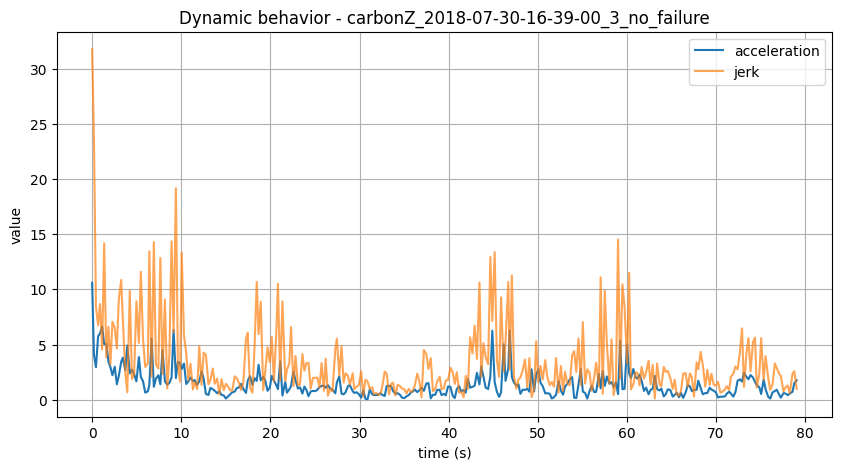

In [ ]:
# Inspeção em um único voo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

flight_name = "carbonZ_2018-07-30-16-39-00_3_no_failure"

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

csv_path = DATA_ROOT / flight_name / "flight_consolidated.csv"

df = pd.read_csv(csv_path)

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["time_s", "vx_mps", "vy_mps"])

t = df["time_s"].to_numpy()
vx = df["vx_mps"].to_numpy()
vy = df["vy_mps"].to_numpy()

eps = 1e-9
dt = np.gradient(t)
dt[dt == 0] = eps

ax = np.gradient(vx) / (dt + eps)
ay = np.gradient(vy) / (dt + eps)

acc = np.sqrt(ax**2 + ay**2)

jx = np.gradient(ax) / (dt + eps)
jy = np.gradient(ay) / (dt + eps)

jerk = np.sqrt(jx**2 + jy**2)

plt.figure(figsize=(10,5))
plt.plot(t, acc, label="acceleration")
plt.plot(t, jerk, label="jerk", alpha=0.7)

plt.xlabel("time (s)")
plt.ylabel("value")
plt.title(f"Dynamic behavior - {flight_name}")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Filtro de eventos no tempo

threshold_jerk = 15  # lembrar de  ajustar depois

anomaly_mask = jerk > threshold_jerk

anomaly_times = t[anomaly_mask]

print("Quantidade de eventos suspeitos:", len(anomaly_times))
print("Primeiros tempos suspeitos:")
print(anomaly_times[:10])

Quantidade de eventos suspeitos: 3
Primeiros tempos suspeitos:
[0.         0.20560241 9.39851522]


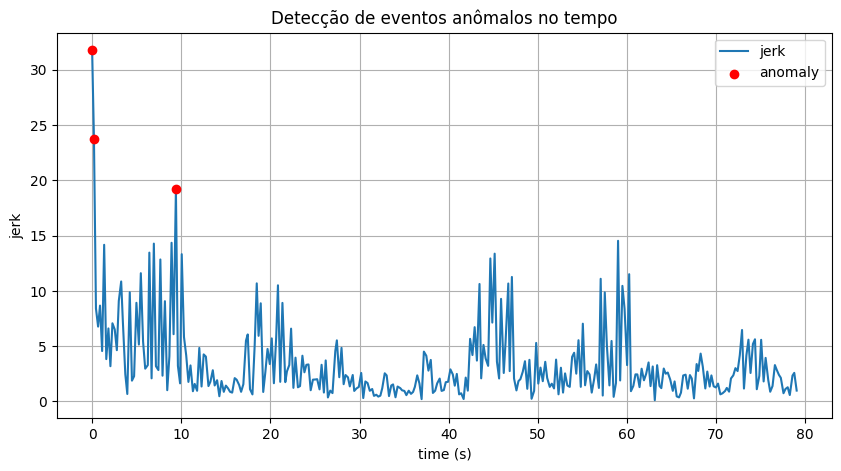

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(t, jerk, label="jerk")

plt.scatter(t[anomaly_mask], jerk[anomaly_mask],
            color="red", label="anomaly", zorder=3)

plt.xlabel("time (s)")
plt.ylabel("jerk")
plt.title("Detecção de eventos anômalos no tempo")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Transformação das detecções isoladas em janelas de eventos contínuos de falha.
events = []

in_event = False
start_time = None

for i in range(len(t)):
    if anomaly_mask[i] and not in_event:
        in_event = True
        start_time = t[i]

    elif not anomaly_mask[i] and in_event:
        end_time = t[i]
        events.append((start_time, end_time))
        in_event = False

# caso termine dentro de um evento
if in_event:
    events.append((start_time, t[-1]))

print("Eventos detectados:")
for e in events:
    print(f"inicio: {e[0]:.2f}s  fim: {e[1]:.2f}s")

Eventos detectados:
inicio: 0.00s  fim: 0.43s
inicio: 9.40s  fim: 9.62s


In [ ]:
# Aplicação de um filtro de persistência temporal para validar anomalias sustentadas.

min_duration = 0.3  # segundos

filtered_events = []

for start, end in events:
    duration = end - start
    if duration >= min_duration:
        filtered_events.append((start, end, duration))

print("Eventos filtrados:")
for start, end, duration in filtered_events:
    print(f"inicio: {start:.2f}s  fim: {end:.2f}s  duracao: {duration:.2f}s")

Eventos filtrados:
inicio: 0.00s  fim: 0.43s  duracao: 0.43s
